In [33]:
import google.auth
import highspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly
import pygsheets
import pypsa
import sys

from helper_functions import get_input_data_sources, load_data, add_network_components, load_data_from_google_sheet
from analysis_functions import capacity_by_country, generation_by_fuel_by_country, generation_by_unit, interconnection_flows, prices, res_curtailment, storage_outputs, hourly_dsf, generation_by_hour_eu, generation_by_hour_by_country

if not sys.warnoptions:
    # used to ignore blank column warning on imports
    import warnings
    warnings.simplefilter("ignore")

plt.rcParams['figure.figsize'] = [15, 9]
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Input parameters & data sources
1. Choose which countries you want to include in the analysis
2. Change LOAD_DATA_SOURCE to either 'remote' or 'local' depending where you are running from (google vm or locally).
3. Provide spreadsheet names for chosen input countries if getting data locally, or urls if using googlesheets

In [34]:
# countries to include in the analysis (WB = Western Balkans, UA = Ukraine + Moldova
EU = True
UK = True
WB = False
UA = False

In [35]:
LOAD_DATA_SOURCE = 'remote' # either local or remote

In [36]:
# URLs (replace with own links to googlesheets if loading remotely, or leave as empty string ) 
EU_URL = "https://docs.google.com/spreadsheets/d/1FmBvSx7I_mEUeI0RTPU7D6FaPoYaf8NN1WtklgyldLk/edit#gid=1021966736"
UK_URL = "https://docs.google.com/spreadsheets/d/1ms5IhiYVat-0gFHnimP5DbfE-dVvLMkKNHn1LMSTrKk/edit#gid=1298949000"
WB_URL = ""
UA_URL = ""


In [37]:
# SPREADSHEETS (replace with own sources if loading locally) 
EU_SHEET = ""
UK_SHEET = ""
WB_SHEET = ""
UA_SHEET = "" 

In [38]:
P_MIN_NUCLEAR = 0.4

In [39]:
OUTPUT_FOLDER = 'outputs/'

### Build network

Read in data sources

In [40]:
input_sources = get_input_data_sources(regions=[EU, UK, WB, UA], data=[EU_URL, UK_URL, WB_URL, UA_URL])

In [42]:
input_dict = load_data(input_data_sources=input_sources, load_data_source=LOAD_DATA_SOURCE)

In [44]:
network = pypsa.Network()
network.set_snapshots(input_dict['load_timeseries'].index)

# building buses and lines
network.import_components_from_dataframe(input_dict['buses'], 'Bus')
network.import_components_from_dataframe(input_dict['cbf_buses'], 'Bus')
network.import_components_from_dataframe(input_dict['buses_hydrogen'], 'Bus')
network.import_components_from_dataframe(input_dict['lines'], 'Line')
network.lines['s_nom_extendable'] = True

# setting co2 emission factors
dict_carriers = {
    'Lignite': 0.334, 'Hard coal': 0.354, 'Gas': 0.187, 'Gas CCS': 0, 'Oil': 0.334, 'Hydrogen': 0, 'Biomass': 0.403,
    'Biogas': 0.178, 'BECCS': 0, 'Geothermal': 0.026, 'Wind': 0, 'Wind offshore': 0, 'PV': 0, 'HPS': 0, 'ROR': 0, 
    'Reservoir' :0,  'Other RES': 0, 'CBF': 0,'VOLL': 0, 'Battery': 0, 'Other storage' : 0, 'Nuclear': 0, 
    'Electrolysis':0, 'Hydrogen storage':0, 'Hydrogen for power':0
}

for carrier in dict_carriers:
    network.add("Carrier", name=carrier, co2_emissions=dict_carriers[carrier])

# add network components
network = add_network_components(network, input_dict, P_MIN_NUCLEAR)

adding links
adding loads
adding RES generation
adding fossil fuel generation
adding bio, hydro + nuclear
adding CHPs
adding storage


### Solve network

In [45]:
network.consistency_check()

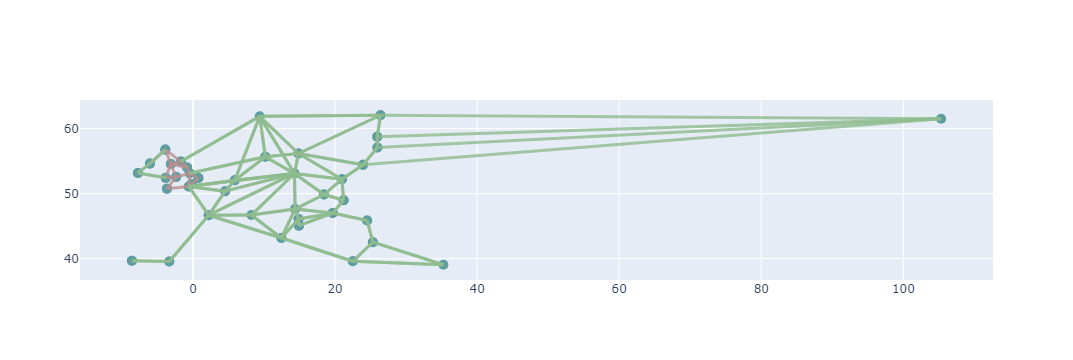

{'data': [{'x': Bus
   EN_NorthEast       -1.719924
   EN_NorthWest       -3.123464
   EN_Yorkshire       -0.825877
   EN_EastMidlands    -0.464704
   EN_WestMidlands    -2.380770
                        ...    
   Romania_H2         24.517011
   Slovakia_H2        21.203613
   Slovenia_H2        14.854420
   Spain_H2           -3.341522
   Sweden_H2          14.845276
   Name: x, Length: 76, dtype: float64,
   'y': Bus
   EN_NorthEast       54.952380
   EN_NorthWest       54.549023
   EN_Yorkshire       54.026822
   EN_EastMidlands    53.134028
   EN_WestMidlands    52.565446
                        ...    
   Romania_H2         45.868492
   Slovakia_H2        48.978414
   Slovenia_H2        46.084302
   Spain_H2           39.556001
   Sweden_H2          56.173846
   Name: y, Length: 76, dtype: float64,
   'text': Index(['Bus EN_NorthEast', 'Bus EN_NorthWest', 'Bus EN_Yorkshire',
          'Bus EN_EastMidlands', 'Bus EN_WestMidlands', 'Bus EN_East',
          'Bus EN_London', 'Bus EN_

In [11]:
#network.iplot()

In [46]:
network.optimize(solver_name='highs')

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████████| 9/9 [00:25<00:00,  2.87s/it]
INFO:linopy.io: Writing time: 181.83s
INFO:linopy.solvers:Log file at /tmp/highs.log.


Running HiGHS 1.5.3 [date: 2023-05-16, git hash: 594fa5a9d-dirty]
Copyright (c) 2023 HiGHS under MIT licence terms
Presolving model
823440 rows, 13679505 cols, 16228616 nonzeros
814866 rows, 5136184 cols, 7203681 nonzeros
814754 rows, 5127407 cols, 7194792 nonzeros
Presolve : Reductions: rows 814754(-39034513); columns 5127407(-14354860); elements 7194792(-54974874)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     3.0003955524e+10 Pr: 385440(4.21144e+09) 39s
      51801     3.0524995013e+10 Pr: 426184(4.41841e+09); Du: 0(3.17199e-05) 45s
      81972     3.1419122029e+10 Pr: 440877(3.99187e+09); Du: 0(6.86901e-05) 51s
      91436     3.1564049200e+10 Pr: 439715(1.17058e+10); Du: 0(6.3364e-05) 56s
     105482     3.2034499518e+10 Pr: 440743(4.37904e+09); Du: 0(6.30947e-05) 62s
     117601     3.2544439694e+10 Pr: 446865(4.37877e+09); Du: 0(7.43482e-05) 67s
     128663     3.2687023631e+10 Pr: 442770(

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 19482267 primals, 39849267 duals
Objective: 7.49e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

### Analysis

In [17]:
# capacity by fuel by country
capacity_output = capacity_by_country(network)

In [45]:
# generation by fuel by country 
generation_by_fuel_by_country_output = generation_by_fuel_by_country(network)

In [34]:
# generation by unit 
generation_by_unit_output = generation_by_unit(network)

In [35]:
# flows
links_output, net_flows_output = interconnection_flows(network)

In [36]:
# prices
prices_output = prices(network)

In [37]:
# curtailment
res_curtailment_output = res_curtailment(network)

In [38]:
# storage 
state_of_charge_output, storage_dispatch_output = storage_outputs(network)

In [39]:
# hourly dsf
hourly_dsf_output = hourly_dsf(network)

In [40]:
# hourly generation
generation_by_hour_by_country_output = generation_by_hour_by_country(network)

In [ ]:
# csv exports
capacity_output.to_csv(OUTPUT_FOLDER + '/capacity_by_fuel_by_country.csv')
generation_by_fuel_by_country_output.to_csv(OUTPUT_FOLDER + '/generation_by_fuel_by_country.csv')
generation_by_unit_output.to_csv(OUTPUT_FOLDER + '/generation_by_unit.csv', encoding='utf-8-sig')
links_output.to_csv(OUTPUT_FOLDER + "/generation_by_link.csv")
net_flows_output.to_csv(OUTPUT_FOLDER + "/net_flows.csv")
prices_output.to_csv(OUTPUT_FOLDER + "/prices.csv")
res_curtailment_output.to_csv(OUTPUT_FOLDER + "/res_curtailment.csv")
state_of_charge_output.to_csv(OUTPUT_FOLDER + "/statge_of_charge.csv")
storage_dispatch_output.to_csv(OUTPUT_FOLDER + "/storage_dispatch.csv")
hourly_dsf_output.to_csv(OUTPUT_FOLDER + "/hourly_dsf.csv")
generation_by_hour_by_country_output.to_csv(OUTPUT_FOLDER + "/generation_by_hour_by_country.csv")

In [59]:
# save input worksheet to repo
with pd.ExcelWriter('input_data.xlsx', engine='openpyxl') as writer:
    for wks in sheet.worksheets():
        df = wks.get_as_df()
        df.to_excel(writer, sheet_name=wks.title, index=False)

/home/harri/venv/lib/python3.9/site-packages/pygsheets/worksheet.py:1554: UserWarning:

At least one column name in the data frame is an empty string. If this is a concern, please specify include_tailing_empty=False and/or ensure that each column containing data has a name.

/home/harri/venv/lib/python3.9/site-packages/pygsheets/worksheet.py:1554: UserWarning:

At least one column name in the data frame is an empty string. If this is a concern, please specify include_tailing_empty=False and/or ensure that each column containing data has a name.



In [60]:
network.export_to_netcdf(path="network.nc")

INFO:pypsa.io:Exported network network.nc has carriers, storage_units, loads, generators, stores, links, buses


<xarray.Dataset>
Dimensions:                            (snapshots: 8760, investment_periods: 0,
                                        carriers_i: 24, storage_units_i: 105,
                                        storage_units_t_p_i: 61,
                                        storage_units_t_p_dispatch_i: 61,
                                        storage_units_t_p_store_i: 61,
                                        storage_units_t_state_of_charge_i: 105,
                                        ...
                                        generators_t_p_i: 1317, stores_i: 35,
                                        stores_t_p_i: 1, stores_t_e_i: 1,
                                        links_i: 201, links_t_p0_i: 162,
                                        links_t_p1_i: 162, buses_i: 72,
                                        buses_t_p_i: 36,
                                        buses_t_marginal_price_i: 38)
Coordinates: (12/24)
  * snapshots                          (snapshots) int64 0 1 2 ... 8758 8759
  * investment_periods                 (investment_periods) int64 
  * carriers_i                         (carriers_i) object 'Lignite' ... 'Hyd...
  * storage_units_i                    (storage_units_i) object 'Austria_HPS'...
  * storage_units_t_p_i                (storage_units_t_p_i) object 'Austria_...
  * storage_units_t_p_dispatch_i       (storage_units_t_p_dispatch_i) object ...
    ...                                 ...
  * links_i                            (links_i) object 'link_AL_XK' ... 'Ukr...
  * links_t_p0_i                       (links_t_p0_i) object 'link_AL_XK' ......
  * links_t_p1_i                       (links_t_p1_i) object 'link_AL_XK' ......
  * buses_i                            (buses_i) object 'Austria' ... 'Ukrain...
  * buses_t_p_i                        (buses_t_p_i) object 'Austria' ... 'UK...
  * buses_t_marginal_price_i           (buses_t_marginal_price_i) object 'Rus...
Data variables: (12/54)
    snapshots_snapshot                 (snapshots) datetime64[ns] 2030-01-01 ...
    snapshots_objective                (snapshots) float64 1.0 1.0 ... 1.0 1.0
    snapshots_stores                   (snapshots) float64 1.0 1.0 ... 1.0 1.0
    snapshots_generators               (snapshots) float64 1.0 1.0 ... 1.0 1.0
    investment_periods_objective       (investment_periods) object 
    investment_periods_years           (investment_periods) object 
    ...                                 ...
    buses_v_nom                        (buses_i) float64 380.0 380.0 ... 1.0 1.0
    buses_x                            (buses_i) float64 14.37 4.524 ... 31.17
    buses_y                            (buses_i) float64 47.63 50.38 ... 48.38
    buses_carrier                      (buses_i) object 'AC' 'AC' ... 'Hydrogen'
    buses_t_p                          (snapshots, buses_t_p_i) float64 -9.09...
    buses_t_marginal_price             (snapshots, buses_t_marginal_price_i) float64 ...
Attributes:
    network__linearized_uc:  0
    network__multi_invest:   0
    network_name:            
    network_objective:       56864065902.05347
    network_pypsa_version:   0.25.2
    network_srid:            4326
    meta:                    {}